Dataset Size : 202599
Device : mps
Epoch=1 Batch=1 G-loss=2.6499 D-loss=0.7065
Epoch=1 Batch=51 G-loss=15.5217 D-loss=0.9392
Epoch=1 Batch=101 G-loss=2.0857 D-loss=0.2155
Epoch=1 Batch=151 G-loss=1.5484 D-loss=0.7764
Epoch=1 Batch=201 G-loss=2.2316 D-loss=0.3289
Epoch=1 Batch=251 G-loss=2.0670 D-loss=0.3504
Epoch=1 Batch=301 G-loss=2.1125 D-loss=0.3977
Epoch=1 Batch=351 G-loss=3.4725 D-loss=0.3240
Epoch=1 Batch=401 G-loss=2.7796 D-loss=0.3105
Epoch=1 Batch=451 G-loss=8.4559 D-loss=0.5942
Epoch=1 Batch=501 G-loss=2.8366 D-loss=0.3547
Epoch=1 Batch=551 G-loss=2.7869 D-loss=0.3024
Epoch=1 Batch=601 G-loss=4.7377 D-loss=0.2470
Epoch=1 Batch=651 G-loss=1.0345 D-loss=0.4562
Epoch=1 Batch=701 G-loss=4.6390 D-loss=0.3857
Epoch=1 Batch=751 G-loss=4.9624 D-loss=0.3115
Epoch=1 Batch=801 G-loss=2.3704 D-loss=0.3318
Epoch=1 Batch=851 G-loss=4.2000 D-loss=0.3446
Epoch=1 Batch=901 G-loss=4.0432 D-loss=0.2047
Epoch=1 Batch=951 G-loss=3.3524 D-loss=0.3271
Epoch=1 Batch=1001 G-loss=3.1993 D-loss=0.1981


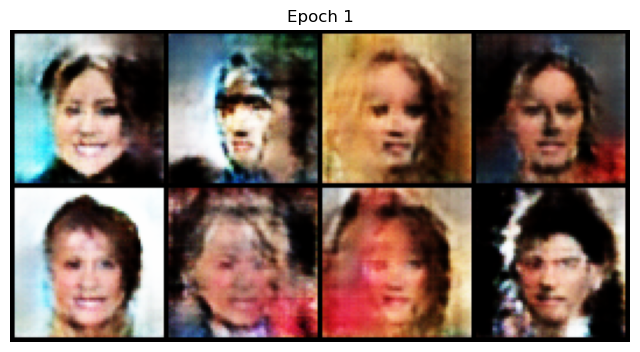

Epoch=2 Batch=1 G-loss=1.7659 D-loss=0.3469
Epoch=2 Batch=51 G-loss=6.1161 D-loss=0.4462


KeyboardInterrupt: 

In [2]:
# ==========================================
# DCGAN ON CELEBA DATASET
# ==========================================

import torch
import os
import torch.nn as nn
import torch.optim as optim
import torchvision
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image


# ==========================================
# DATASET
# ==========================================

class ImageProcessor(Dataset):

    def __init__(self, root_dir_path, transformations=None):

        self.root_dir_path = root_dir_path
        self.transformations = transformations

        self.all_img_path = [
            os.path.join(root_dir_path, img)
            for img in os.listdir(root_dir_path)
        ]

    def __len__(self):
        return len(self.all_img_path)

    def __getitem__(self, idx):

        img_path = self.all_img_path[idx]

        img = Image.open(img_path).convert("RGB")

        if self.transformations:
            img = self.transformations(img)

        return img


# ==========================================
# TRANSFORMATIONS
# ==========================================

root_dir_path = "./img_align_celeba"

transformations = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

dataset = ImageProcessor(
    root_dir_path,
    transformations
)

dataloader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

print("Dataset Size :", len(dataset))


# ==========================================
# GENERATOR
# ==========================================

class Generator(nn.Module):

    def __init__(self, z_dim=100, img_channels=3):
        super().__init__()

        self.model = nn.Sequential(

            nn.ConvTranspose2d(
                z_dim,
                512,
                kernel_size=4,
                stride=1,
                padding=0,
                bias=False
            ),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                512,
                256,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                256,
                128,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                128,
                64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                64,
                img_channels,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)


# ==========================================
# DISCRIMINATOR
# ==========================================

class Discriminator(nn.Module):

    def __init__(self, img_channels=3):
        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(
                img_channels,
                64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                64,
                128,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                128,
                256,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                256,
                512,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                512,
                1,
                kernel_size=4,
                stride=1,
                padding=0,
                bias=False
            ),

            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img).view(-1, 1)


# ==========================================
# LOSS + MODELS + OPTIMIZERS
# ==========================================

GAN_loss = nn.BCELoss()

g = Generator()
d = Discriminator()

g_optimizer = optim.Adam(
    g.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

d_optimizer = optim.Adam(
    d.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)


# ==========================================
# DEVICE
# ==========================================

if torch.backends.mps.is_available():
    device = torch.device("mps")

elif torch.cuda.is_available():
    device = torch.device("cuda")

else:
    device = torch.device("cpu")

print("Device :", device)

g = g.to(device)
d = d.to(device)


# ==========================================
# IMAGE VISUALIZATION
# ==========================================

def save_generated_images(
    g,
    epoch,
    device,
    num_imgs=8
):

    z = torch.randn(
        num_imgs,
        100,
        1,
        1
    ).to(device)

    generated_imgs = g(z).detach().cpu()

    grid = torchvision.utils.make_grid(
        generated_imgs,
        nrow=4,
        normalize=True
    )

    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(f"Epoch {epoch+1}")
    plt.axis("off")
    plt.show()


# ==========================================
# TRAINING LOOP
# ==========================================

def train(
    g,
    d,
    dataloader,
    epochs=10
):

    for epoch in range(epochs):

        for i, img in enumerate(dataloader):

            real_imgs = img.to(device)

            batch_size = real_imgs.size(0)

            real_labels = torch.ones(
                batch_size,
                1
            ).to(device)

            fake_labels = torch.zeros(
                batch_size,
                1
            ).to(device)

            # ---------------------
            # Train Discriminator
            # ---------------------

            d_optimizer.zero_grad()

            z = torch.randn(
                batch_size,
                100,
                1,
                1
            ).to(device)

            fake_imgs = g(z)

            real_loss = GAN_loss(
                d(real_imgs),
                real_labels
            )

            fake_loss = GAN_loss(
                d(fake_imgs.detach()),
                fake_labels
            )

            d_loss = (
                real_loss + fake_loss
            ) / 2

            d_loss.backward()

            d_optimizer.step()

            # ---------------------
            # Train Generator
            # ---------------------

            g_optimizer.zero_grad()

            g_loss = GAN_loss(
                d(fake_imgs),
                real_labels
            )

            g_loss.backward()

            g_optimizer.step()

            if i % 50 == 0:

                print(
                    f"Epoch={epoch+1} "
                    f"Batch={i+1} "
                    f"G-loss={g_loss.item():.4f} "
                    f"D-loss={d_loss.item():.4f}"
                )

        save_generated_images(
            g,
            epoch,
            device
        )


# ==========================================
# START TRAINING
# ==========================================

train(
    g,
    d,
    dataloader,
    epochs=10
)